# Manufacturing Predictive Maintenance
## End-to-End Exploratory Data Analysis (EDA)

**Industry:** Manufacturing / Industrial Analytics  
**Dataset:** AI4I 2020 Predictive Maintenance — UCI Machine Learning Repository  
**Primary Business Goal:** Understand operating conditions associated with machine failure before building a predictive-maintenance model.

### Why this project matters
In manufacturing, unexpected equipment failure can create production downtime, emergency maintenance cost, missed schedules and inefficient use of technicians and spare parts. EDA is the first stage of converting sensor data into maintenance intelligence.

This notebook follows a professional analytics workflow:

**Business Understanding → Data Audit → Cleaning → Feature Engineering → Univariate EDA → Outliers → Bivariate EDA → Multivariate EDA → Statistical Tests → Failure-Mode Diagnostics → Business Recommendations**

## 1. Business Questions

1. What is the baseline machine-failure rate?
2. Is failure risk different across product types?
3. Which operating variables look different when machines fail?
4. Does failure risk change across operating ranges?
5. Which failure modes are most common?
6. Can engineering-derived features reveal clearer risk zones?
7. What should a plant maintenance team monitor or investigate?

## 2. Dataset Description

The AI4I 2020 dataset contains 10,000 observations from a synthetic manufacturing process designed to reflect predictive-maintenance conditions encountered in industry.

Core variables include:

| Variable | Meaning |
|---|---|
| UDI / UID | Unique observation identifier |
| Product ID | Product identifier |
| Type | Product quality/type category |
| Air temperature | Ambient temperature in Kelvin |
| Process temperature | Process temperature in Kelvin |
| Rotational speed | Shaft speed in rpm |
| Torque | Mechanical torque in Nm |
| Tool wear | Accumulated tool usage in minutes |
| Machine failure | Overall binary failure flag |
| TWF | Tool Wear Failure |
| HDF | Heat Dissipation Failure |
| PWF | Power Failure |
| OSF | Overstrain Failure |
| RNF | Random Failure |

**Source:** UCI Machine Learning Repository, AI4I 2020 Predictive Maintenance Dataset  
**DOI:** 10.24432/C5HS5C

In [1]:
from pathlib import Path
from io import BytesIO
import urllib.request
import zipfile
import warnings
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, chi2_contingency

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

BASE = Path.cwd()
DATA_DIR = BASE / "data"
OUTPUT_DIR = BASE / "output"
FIG_DIR = BASE / "figures"

for folder in [DATA_DIR, OUTPUT_DIR, FIG_DIR]:
    folder.mkdir(exist_ok=True)

print("Project folder:", BASE)

Project folder: C:\Users\shada\Downloads


## 3. Load the Dataset

The cell below first looks for a local copy at `data/ai4i2020.csv`.  
If it is missing, it attempts to download the official ZIP from UCI and saves the CSV locally.

In [2]:
DATA_FILE = DATA_DIR / "ai4i2020.csv"
UCI_ZIP = "https://archive.ics.uci.edu/static/public/601/ai4i%2B2020%2Bpredictive%2Bmaintenance%2Bdataset.zip"

def load_ai4i_data():
    if DATA_FILE.exists():
        print("Loading local dataset:", DATA_FILE)
        return pd.read_csv(DATA_FILE)

    print("Local file not found. Downloading from UCI...")
    try:
        with urllib.request.urlopen(UCI_ZIP, timeout=60) as response:
            payload = response.read()

        with zipfile.ZipFile(BytesIO(payload)) as zf:
            csv_names = [name for name in zf.namelist() if name.lower().endswith(".csv")]
            if not csv_names:
                raise FileNotFoundError("CSV not found inside downloaded ZIP.")
            with zf.open(csv_names[0]) as file:
                data = pd.read_csv(file)

        data.to_csv(DATA_FILE, index=False)
        print("Saved local copy:", DATA_FILE)
        return data

    except Exception as exc:
        raise RuntimeError(
            "Automatic download failed. Download ai4i2020.csv from the official UCI "
            f"AI4I 2020 dataset page and place it at: {DATA_FILE}\n\nOriginal error: {exc}"
        )

raw_df = load_ai4i_data()
raw_df.head()

Local file not found. Downloading from UCI...
Saved local copy: C:\Users\shada\Downloads\data\ai4i2020.csv


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.100,308.600,1551,42.800,0,0,0,0,0,0,0
1,2,L47181,L,298.200,308.700,1408,46.300,3,0,0,0,0,0,0
2,3,L47182,L,298.100,308.500,1498,49.400,5,0,0,0,0,0,0
3,4,L47183,L,298.200,308.600,1433,39.500,7,0,0,0,0,0,0
4,5,L47184,L,298.200,308.700,1408,40.000,9,0,0,0,0,0,0


## 4. Initial Data Understanding

In [3]:
print("Rows:", raw_df.shape[0])
print("Columns:", raw_df.shape[1])
print("\nColumn names:")
print(raw_df.columns.tolist())

Rows: 10000
Columns: 14

Column names:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [4]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [5]:
raw_df.head(10)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.100,308.600,1551,42.800,0,0,0,0,0,0,0
1,2,L47181,L,298.200,308.700,1408,46.300,3,0,0,0,0,0,0
2,3,L47182,L,298.100,308.500,1498,49.400,5,0,0,0,0,0,0
3,4,L47183,L,298.200,308.600,1433,39.500,7,0,0,0,0,0,0
4,5,L47184,L,298.200,308.700,1408,40.000,9,0,0,0,0,0,0
5,6,M14865,M,298.100,308.600,1425,41.900,11,0,0,0,0,0,0
6,7,L47186,L,298.100,308.600,1558,42.400,14,0,0,0,0,0,0
7,8,L47187,L,298.100,308.600,1527,40.200,16,0,0,0,0,0,0
8,9,M14868,M,298.300,308.700,1667,28.600,18,0,0,0,0,0,0
9,10,M14869,M,298.500,309.000,1741,28.000,21,0,0,0,0,0,0


In [6]:
raw_df.tail()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9995,9996,M24855,M,298.800,308.400,1604,29.500,14,0,0,0,0,0,0
9996,9997,H39410,H,298.900,308.400,1632,31.800,17,0,0,0,0,0,0
9997,9998,M24857,M,299.000,308.600,1645,33.400,22,0,0,0,0,0,0
9998,9999,H39412,H,299.000,308.700,1408,48.500,25,0,0,0,0,0,0
9999,10000,M24859,M,299.000,308.700,1500,40.200,30,0,0,0,0,0,0


### Observation
At this stage, do not start deleting columns or outliers. First understand what each column represents and whether it is an identifier, operating feature, target, or failure-mode indicator.

## 5. Standardize Column Names

In [3]:
COLUMN_MAP = {
    "UDI": "udi",
    "UID": "udi",
    "Product ID": "product_id",
    "Type": "type",
    "Air temperature [K]": "air_temperature_k",
    "Process temperature [K]": "process_temperature_k",
    "Rotational speed [rpm]": "rotational_speed_rpm",
    "Torque [Nm]": "torque_nm",
    "Tool wear [min]": "tool_wear_min",
    "Machine failure": "machine_failure",
    "TWF": "twf",
    "HDF": "hdf",
    "PWF": "pwf",
    "OSF": "osf",
    "RNF": "rnf",
}

df = raw_df.rename(columns=COLUMN_MAP).copy()
df.columns.tolist()

['udi',
 'product_id',
 'type',
 'air_temperature_k',
 'process_temperature_k',
 'rotational_speed_rpm',
 'torque_nm',
 'tool_wear_min',
 'machine_failure',
 'twf',
 'hdf',
 'pwf',
 'osf',
 'rnf']

## 6. Data Quality Audit

In [8]:
quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(),
})
quality_summary

,dtype,missing_count,missing_pct,unique_values
udi,int64,0,0.000,10000
product_id,object,0,0.000,10000
type,object,0,0.000,3
air_temperature_k,float64,0,0.000,93
process_temperature_k,float64,0,0.000,82
rotational_speed_rpm,int64,0,0.000,941
torque_nm,float64,0,0.000,577
tool_wear_min,int64,0,0.000,246
machine_failure,int64,0,0.000,2
twf,int64,0,0.000,2


In [4]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate UDI values:", df["udi"].duplicated().sum() if "udi" in df else "N/A")
print("Duplicate Product IDs:", df["product_id"].duplicated().sum() if "product_id" in df else "N/A")

Duplicate rows: 0
Duplicate UDI values: 0
Duplicate Product IDs: 0


In [5]:
# Check categorical values and binary flags
print("Product types:", sorted(df["type"].dropna().unique().tolist()))

binary_cols = ["machine_failure", "twf", "hdf", "pwf", "osf", "rnf"]
for col in binary_cols:
    print(col, "->", sorted(df[col].dropna().unique().tolist()))

Product types: ['H', 'L', 'M']
machine_failure -> [0, 1]
twf -> [0, 1]
hdf -> [0, 1]
pwf -> [0, 1]
osf -> [0, 1]
rnf -> [0, 1]


### Data-cleaning decision
- Missing values, duplicates and invalid categories should be handled if discovered.
- `udi` and `product_id` are identifiers. They are useful for traceability but should not be interpreted as physical causes of failure.
- Extreme sensor readings are **not automatically removed**, because abnormal operating conditions may be exactly where failures occur.

## 7. Descriptive Statistics

In [6]:
base_numeric = [
    "air_temperature_k",
    "process_temperature_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min",
]

df[base_numeric].describe().T

,count,mean,std,min,25%,50%,75%,max
air_temperature_k,"10,000.000",300.005,2.000,295.300,298.300,300.100,301.500,304.500
process_temperature_k,"10,000.000",310.006,1.484,305.700,308.800,310.100,311.100,313.800
rotational_speed_rpm,"10,000.000","1,538.776",179.284,"1,168.000","1,423.000","1,503.000","1,612.000","2,886.000"
torque_nm,"10,000.000",39.987,9.969,3.800,33.200,40.100,46.800,76.600
tool_wear_min,"10,000.000",107.951,63.654,0.000,53.000,108.000,162.000,253.000


In [7]:
categorical_summary = pd.DataFrame({
    "count": df["type"].value_counts(),
    "percentage": (df["type"].value_counts(normalize=True) * 100).round(2)
})
categorical_summary

,count,percentage
type,,
L,6000,60.000
M,2997,29.970
H,1003,10.030


## 8. Target Variable — Machine Failure

In [8]:
failure_summary = df["machine_failure"].value_counts().sort_index().rename_axis("machine_failure").to_frame("count")
failure_summary["percentage"] = (failure_summary["count"] / len(df) * 100).round(2)
failure_summary

,count,percentage
machine_failure,,
0,9661,96.610
1,339,3.390


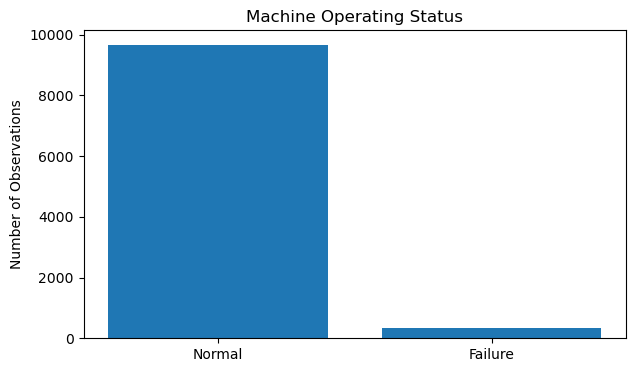

In [9]:
plt.figure(figsize=(7, 4))
counts = df["machine_failure"].value_counts().sort_index()
plt.bar(["Normal", "Failure"], counts.values)
plt.title("Machine Operating Status")
plt.ylabel("Number of Observations")
plt.show()

### Interpretation
Failure should be discussed as a **rate**, not only a count. In rare-event datasets a count chart can visually hide the minority class even when that minority is operationally important.

## 9. Feature Engineering

In [10]:
eda = df.copy()

# Thermal gap
eda["temperature_difference_k"] = (
    eda["process_temperature_k"] - eda["air_temperature_k"]
)

# Mechanical power: Torque × angular speed
eda["mechanical_power_w"] = (
    eda["torque_nm"] * eda["rotational_speed_rpm"] * 2 * np.pi / 60
)

# Combined wear + load indicator
eda["wear_load_index"] = eda["tool_wear_min"] * eda["torque_nm"]

# Operational wear bands
eda["tool_wear_band"] = pd.cut(
    eda["tool_wear_min"],
    bins=[-1, 50, 100, 150, 200, np.inf],
    labels=["0-50", "51-100", "101-150", "151-200", "200+"],
)

eda[[
    "temperature_difference_k",
    "mechanical_power_w",
    "wear_load_index",
    "tool_wear_band",
]].head()

,temperature_difference_k,mechanical_power_w,wear_load_index,tool_wear_band
0,10.500,"6,951.591",0.000,0-50
1,10.500,"6,826.723",138.900,0-50
2,10.400,"7,749.388",247.000,0-50
3,10.400,"5,927.505",276.500,0-50
4,10.500,"5,897.817",360.000,0-50


### Why engineer these variables?

Raw sensors are useful, but industrial analysis becomes more interpretable when variables are connected to operating physics.

- **Temperature difference** helps describe heat-dissipation conditions.
- **Mechanical power** combines rotational speed and torque.
- **Wear-load index** combines cumulative tool wear with mechanical load.

## 10. Univariate Analysis — Numerical Features

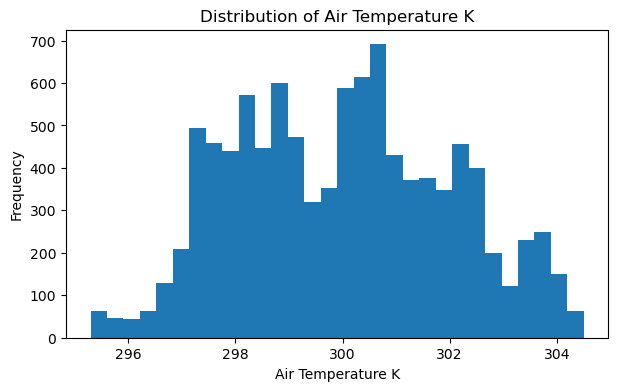

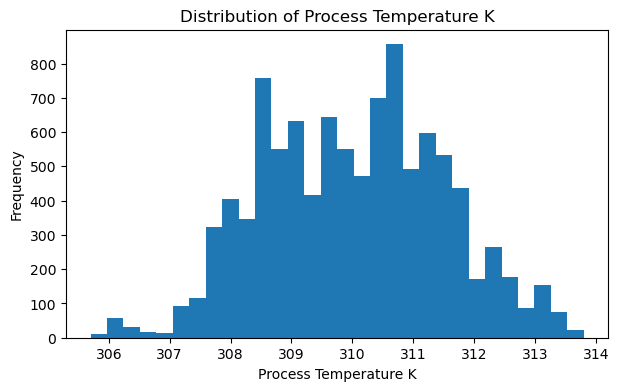

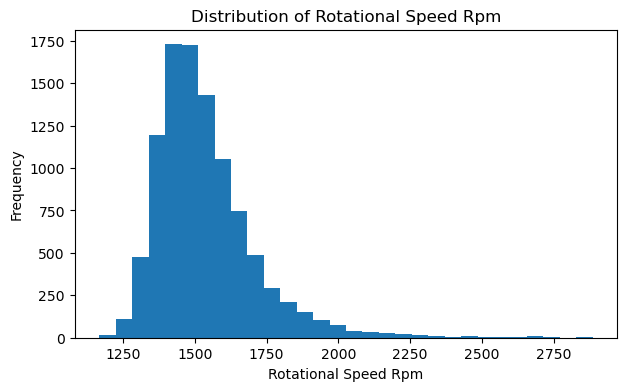

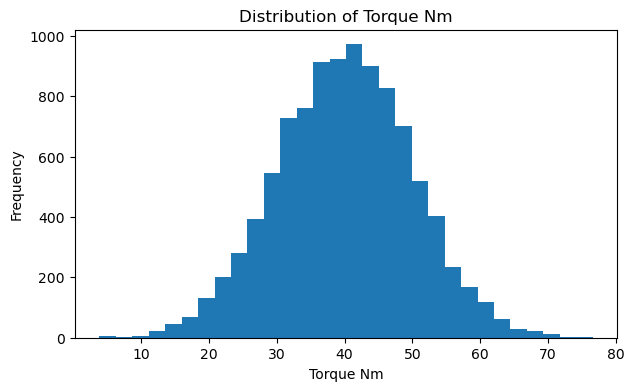

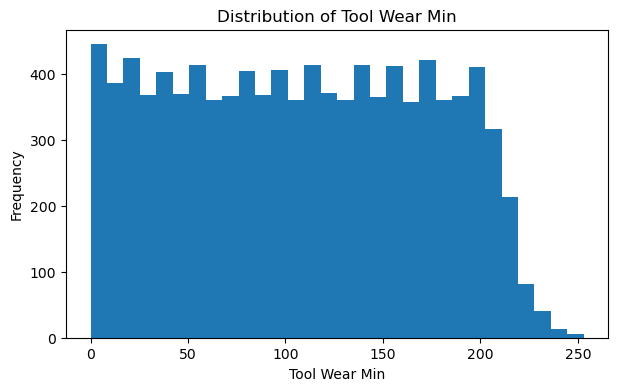

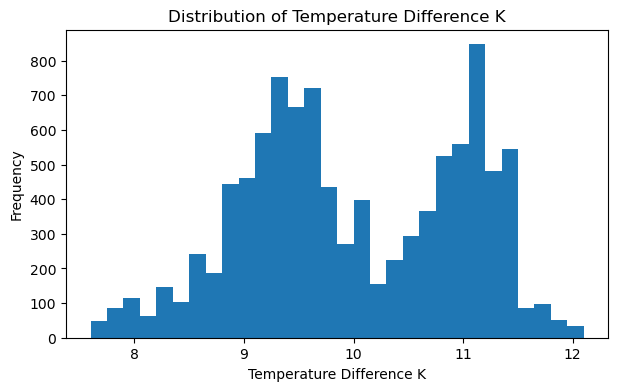

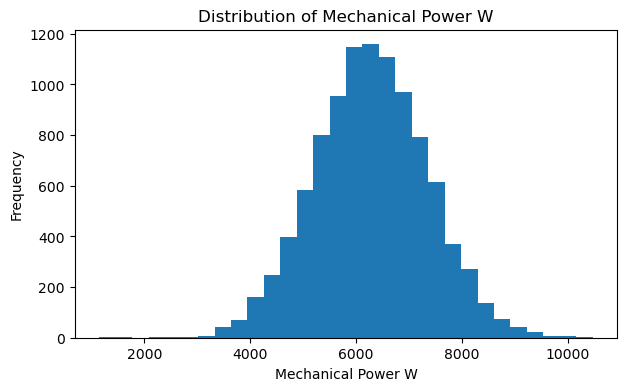

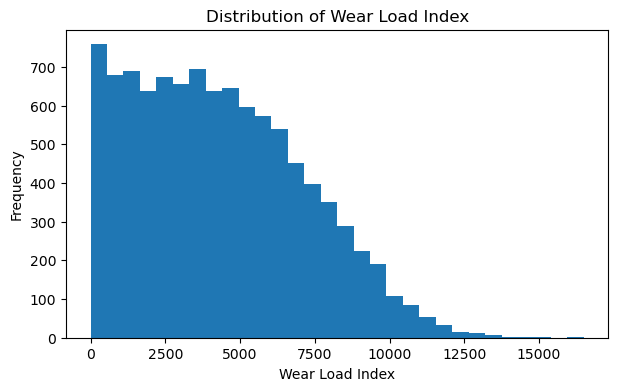

In [11]:
numeric_features = [
    "air_temperature_k",
    "process_temperature_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min",
    "temperature_difference_k",
    "mechanical_power_w",
    "wear_load_index",
]

for col in numeric_features:
    plt.figure(figsize=(7, 4))
    plt.hist(eda[col].dropna(), bins=30)
    plt.title(f"Distribution of {col.replace('_', ' ').title()}")
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Frequency")
    plt.show()

## 11. Outlier Analysis

In [12]:
outlier_rows = []

for col in numeric_features:
    q1 = eda[col].quantile(0.25)
    q3 = eda[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (eda[col] < lower) | (eda[col] > upper)

    outlier_rows.append({
        "feature": col,
        "q1": q1,
        "q3": q3,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(mask.sum()),
        "outlier_pct": mask.mean() * 100,
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_pct", ascending=False)
outlier_summary

,feature,q1,q3,lower_bound,upper_bound,outlier_count,outlier_pct
2,rotational_speed_rpm,"1,423.000","1,612.000","1,139.500","1,895.500",418,4.180
3,torque_nm,33.200,46.800,12.800,67.200,69,0.690
6,mechanical_power_w,"5,561.184","7,003.003","3,398.457","9,165.730",60,0.600
7,wear_load_index,"1,963.650","6,279.000","-4,509.375","12,752.025",20,0.200
0,air_temperature_k,298.300,301.500,293.500,306.300,0,0.000
1,process_temperature_k,308.800,311.100,305.350,314.550,0,0.000
4,tool_wear_min,53.000,162.000,-110.500,325.500,0,0.000
5,temperature_difference_k,9.300,11.000,6.750,13.550,0,0.000


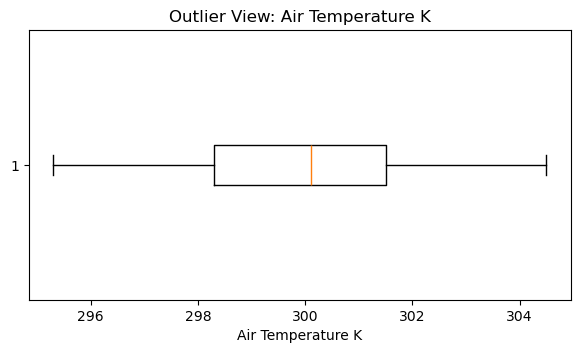

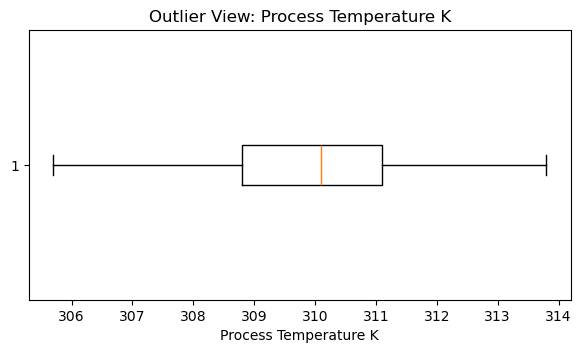

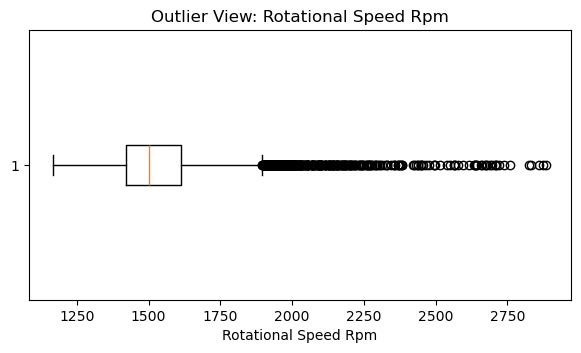

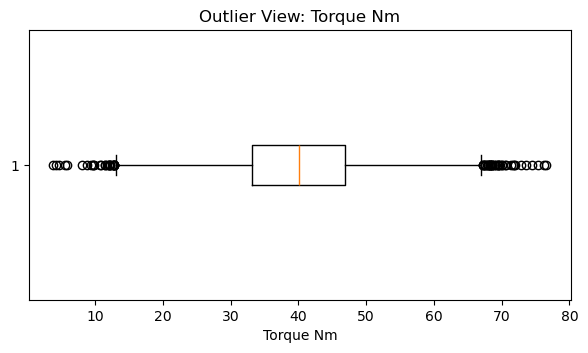

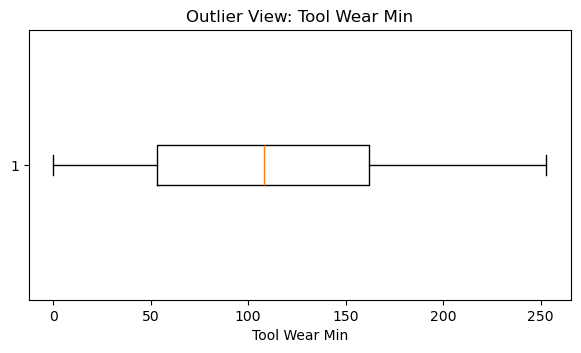

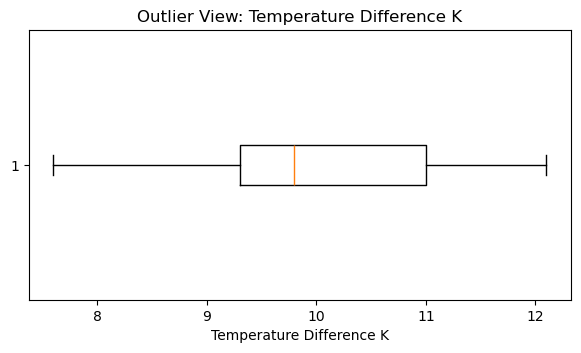

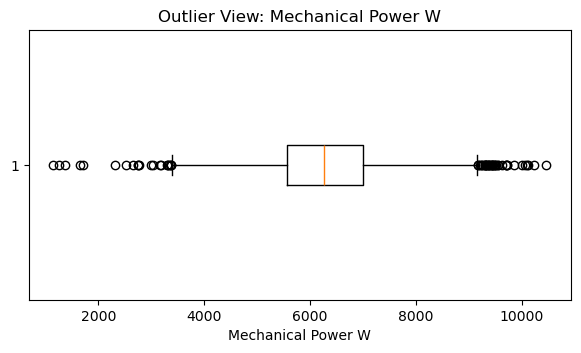

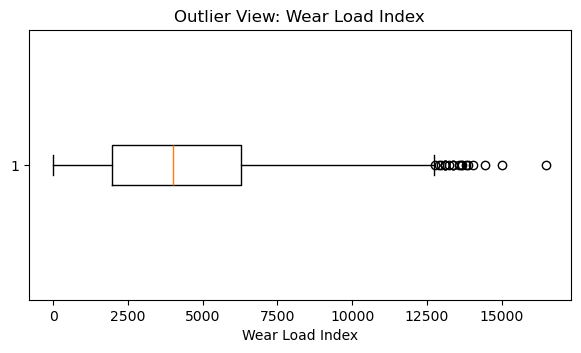

In [13]:
for col in numeric_features:
    plt.figure(figsize=(7, 3.5))
    plt.boxplot(eda[col].dropna(), vert=False)
    plt.title(f"Outlier View: {col.replace('_', ' ').title()}")
    plt.xlabel(col.replace("_", " ").title())
    plt.show()

### Important EDA principle
Do not remove an observation merely because the IQR rule calls it an outlier. In predictive maintenance, an extreme speed, torque, power or wear value may represent an unsafe operating condition rather than bad data.

## 12. Failure Rate by Product Type

In [14]:
failure_by_type = eda.groupby("type", observed=False).agg(
    observations=("machine_failure", "size"),
    failures=("machine_failure", "sum"),
    failure_rate_pct=("machine_failure", lambda x: x.mean() * 100),
).reset_index()

failure_by_type["failure_rate_pct"] = failure_by_type["failure_rate_pct"].round(2)
failure_by_type

,type,observations,failures,failure_rate_pct
0,H,1003,21,2.090
1,L,6000,235,3.920
2,M,2997,83,2.770


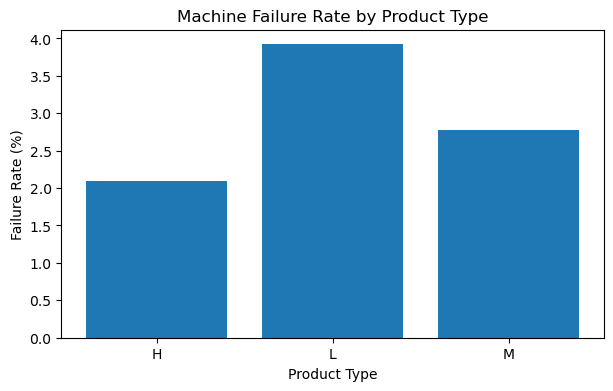

In [15]:
plt.figure(figsize=(7, 4))
plt.bar(failure_by_type["type"], failure_by_type["failure_rate_pct"])
plt.title("Machine Failure Rate by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Failure Rate (%)")
plt.show()

### Interpretation prompt
Compare **failure rate**, not just the number of failures. A category with more observations can naturally produce more failure events even when its underlying risk is not higher.

## 13. Numerical Features by Machine Status

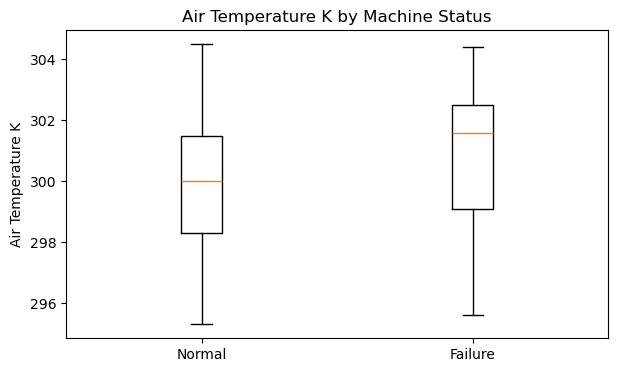

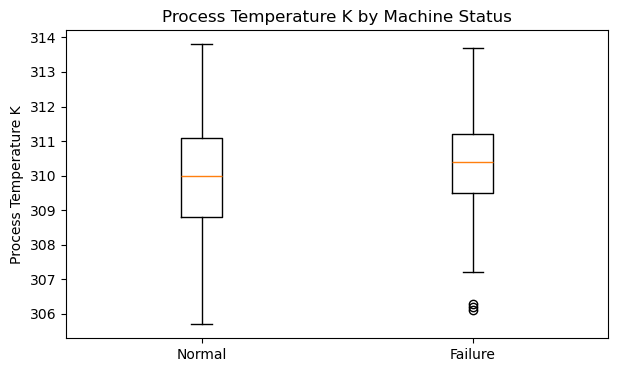

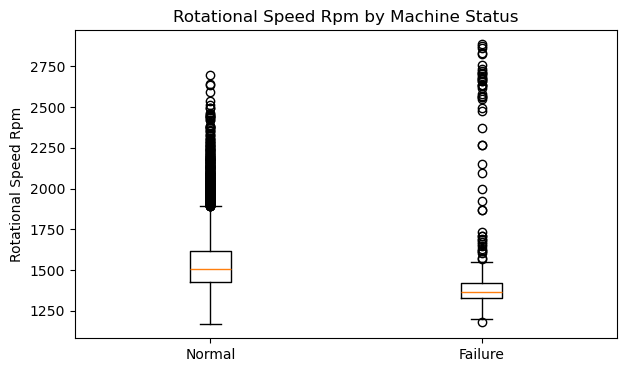

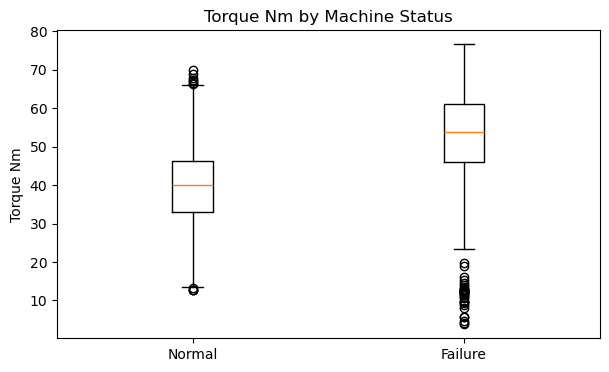

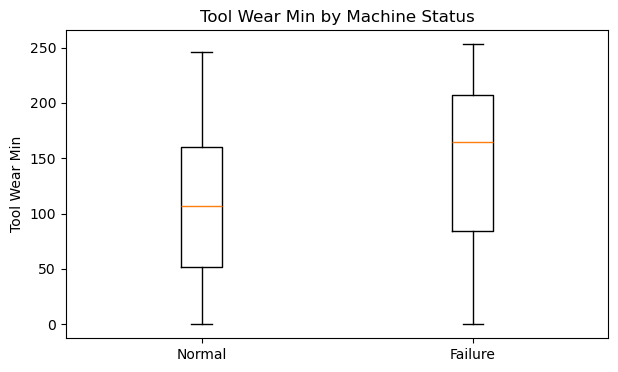

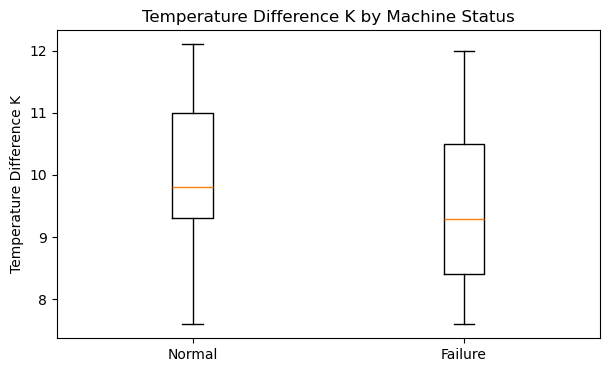

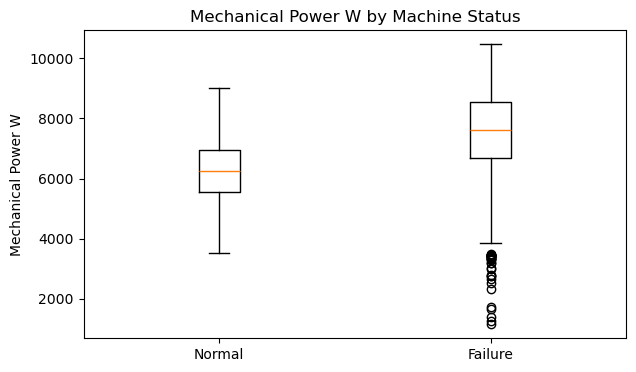

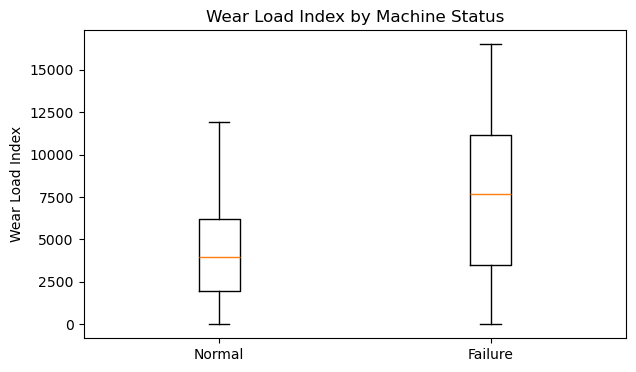

In [16]:
for col in numeric_features:
    normal_vals = eda.loc[eda["machine_failure"] == 0, col].dropna()
    failure_vals = eda.loc[eda["machine_failure"] == 1, col].dropna()

    plt.figure(figsize=(7, 4))
    plt.boxplot([normal_vals, failure_vals], tick_labels=["Normal", "Failure"])
    plt.title(f"{col.replace('_', ' ').title()} by Machine Status")
    plt.ylabel(col.replace("_", " ").title())
    plt.show()

In [ ]:
comparison = eda.groupby("machine_failure")[numeric_features].agg(["mean", "median"])
comparison.T

## 14. Failure Rate Across Operating Ranges

In [17]:
def failure_rate_by_quantile(data, feature, q=5):
    temp = data[[feature, "machine_failure"]].dropna().copy()
    temp["band"] = pd.qcut(temp[feature], q=q, duplicates="drop")
    result = temp.groupby("band", observed=False).agg(
        observations=("machine_failure", "size"),
        failures=("machine_failure", "sum"),
        failure_rate_pct=("machine_failure", lambda x: x.mean() * 100),
    )
    return result

for feature in [
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min",
    "temperature_difference_k",
    "mechanical_power_w",
    "wear_load_index",
]:
    print("\n", feature.upper())
    display(failure_rate_by_quantile(eda, feature))


 ROTATIONAL_SPEED_RPM


,observations,failures,failure_rate_pct
band,,,
"(1167.999, 1405.0]",2007,244,12.157
"(1405.0, 1470.0]",2011,29,1.442
"(1470.0, 1541.0]",1999,12,0.600
"(1541.0, 1644.0]",1992,9,0.452
"(1644.0, 2886.0]",1991,45,2.260



 TORQUE_NM


,observations,failures,failure_rate_pct
band,,,
"(3.799, 31.4]",2002,47,2.348
"(31.4, 37.5]",2012,9,0.447
"(37.5, 42.7]",2018,12,0.595
"(42.7, 48.3]",1985,43,2.166
"(48.3, 76.6]",1983,228,11.498



 TOOL_WEAR_MIN


...

,observations,failures,failure_rate_pct
band,,,
"(7.598999999999999, 9.1]",2092,159,7.600
"(9.1, 9.6]",1986,51,2.568
"(9.6, 10.4]",1986,40,2.014
"(10.4, 11.1]",1974,48,2.432
"(11.1, 12.1]",1962,41,2.090



 MECHANICAL_POWER_W


,observations,failures,failure_rate_pct
band,,,
"(1148.44, 5383.01]",2000,46,2.300
"(5383.01, 6007.911]",2000,13,0.650
"(6007.911, 6546.606]",2000,21,1.050
"(6546.606, 7176.204]",2000,50,2.500
"(7176.204, 10469.923]",2000,209,10.450



 WEAR_LOAD_INDEX


,observations,failures,failure_rate_pct
band,,,
"(-0.001, 1552.94]",2000,53,2.650
"(1552.94, 3211.52]",2000,27,1.350
"(3211.52, 4892.4]",2001,31,1.549
"(4892.4, 6874.04]",1999,42,2.101
"(6874.04, 16497.0]",2000,186,9.300


## 15. Tool Wear and Failure Risk

In [18]:
wear_failure = eda.groupby("tool_wear_band", observed=False).agg(
    observations=("machine_failure", "size"),
    failures=("machine_failure", "sum"),
    failure_rate_pct=("machine_failure", lambda x: x.mean() * 100),
).reset_index()
wear_failure["failure_rate_pct"] = wear_failure["failure_rate_pct"].round(2)
wear_failure

,tool_wear_band,observations,failures,failure_rate_pct
0,0-50,2396,52,2.170
1,51-100,2271,53,2.330
2,101-150,2295,50,2.180
3,151-200,2276,66,2.900
4,200+,762,118,15.490


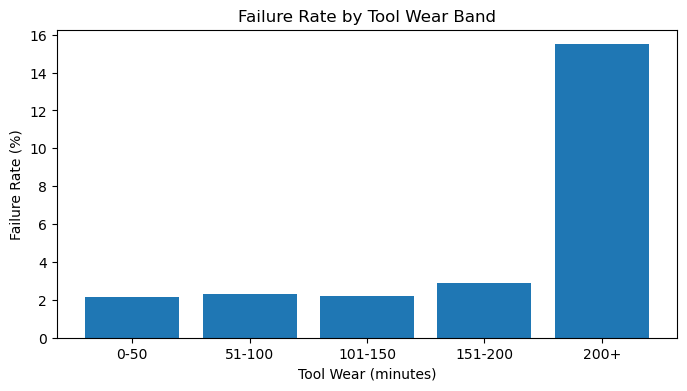

In [19]:
plt.figure(figsize=(8, 4))
plt.bar(wear_failure["tool_wear_band"].astype(str), wear_failure["failure_rate_pct"])
plt.title("Failure Rate by Tool Wear Band")
plt.xlabel("Tool Wear (minutes)")
plt.ylabel("Failure Rate (%)")
plt.show()

## 16. Multivariate EDA — Rotational Speed vs Torque

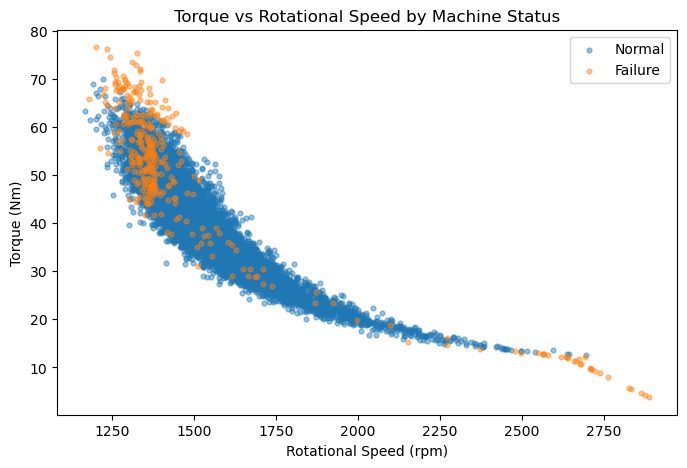

In [20]:
plt.figure(figsize=(8, 5))
for status, group in eda.groupby("machine_failure"):
    plt.scatter(
        group["rotational_speed_rpm"],
        group["torque_nm"],
        s=12,
        alpha=0.45,
        label="Failure" if status == 1 else "Normal",
    )

plt.xlabel("Rotational Speed (rpm)")
plt.ylabel("Torque (Nm)")
plt.title("Torque vs Rotational Speed by Machine Status")
plt.legend()
plt.show()

### Why this chart matters
Torque and rotational speed jointly determine mechanical power. A machine can therefore operate in an unusual power regime even when one of the two individual variables does not look extreme by itself.

## 17. Multivariate EDA — Thermal Gap vs Rotational Speed

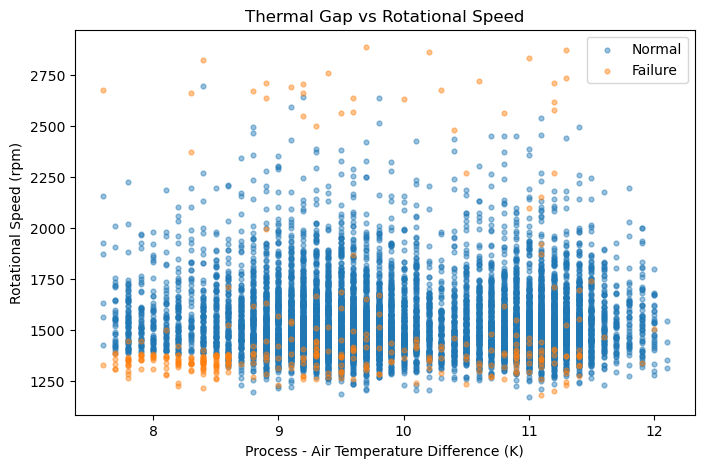

In [21]:
plt.figure(figsize=(8, 5))
for status, group in eda.groupby("machine_failure"):
    plt.scatter(
        group["temperature_difference_k"],
        group["rotational_speed_rpm"],
        s=12,
        alpha=0.45,
        label="Failure" if status == 1 else "Normal",
    )

plt.xlabel("Process - Air Temperature Difference (K)")
plt.ylabel("Rotational Speed (rpm)")
plt.title("Thermal Gap vs Rotational Speed")
plt.legend()
plt.show()

## 18. Correlation Analysis

In [22]:
corr_cols = numeric_features + ["machine_failure", "twf", "hdf", "pwf", "osf", "rnf"]
corr = eda[corr_cols].corr(numeric_only=True)
corr.round(3)

,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,temperature_difference_k,mechanical_power_w,wear_load_index,machine_failure,twf,hdf,pwf,osf,rnf
air_temperature_k,1.000,0.876,0.023,-0.014,0.014,-0.700,-0.011,0.007,0.083,0.010,0.138,0.003,0.002,0.018
process_temperature_k,0.876,1.000,0.019,-0.014,0.013,-0.268,-0.011,0.006,0.036,0.007,0.057,-0.003,0.005,0.022
rotational_speed_rpm,0.023,0.019,1.000,-0.875,0.000,-0.017,-0.806,-0.331,-0.044,0.010,-0.121,0.123,-0.105,-0.013
torque_nm,-0.014,-0.014,-0.875,1.000,-0.003,0.007,0.979,0.377,0.191,-0.015,0.143,0.084,0.183,0.016
tool_wear_min,0.014,0.013,0.000,-0.003,1.000,-0.008,-0.003,0.898,0.105,0.116,-0.001,-0.009,0.156,0.011
temperature_difference_k,-0.700,-0.268,-0.017,0.007,-0.008,1.000,0.007,-0.005,-0.112,-0.009,-0.191,-0.012,0.003,-0.002
mechanical_power_w,-0.011,-0.011,-0.806,0.979,-0.003,0.007,1.000,0.369,0.176,-0.017,0.117,0.089,0.182,0.017
wear_load_index,0.007,0.006,-0.331,0.377,0.898,-0.005,0.369,1.000,0.190,0.093,0.053,0.024,0.273,0.016
machine_failure,0.083,0.036,-0.044,0.191,0.105,-0.112,0.176,0.190,1.000,0.363,0.576,0.523,0.531,0.005
twf,0.010,0.007,0.010,-0.015,0.116,-0.009,-0.017,0.093,0.363,1.000,-0.007,0.009,0.038,0.031


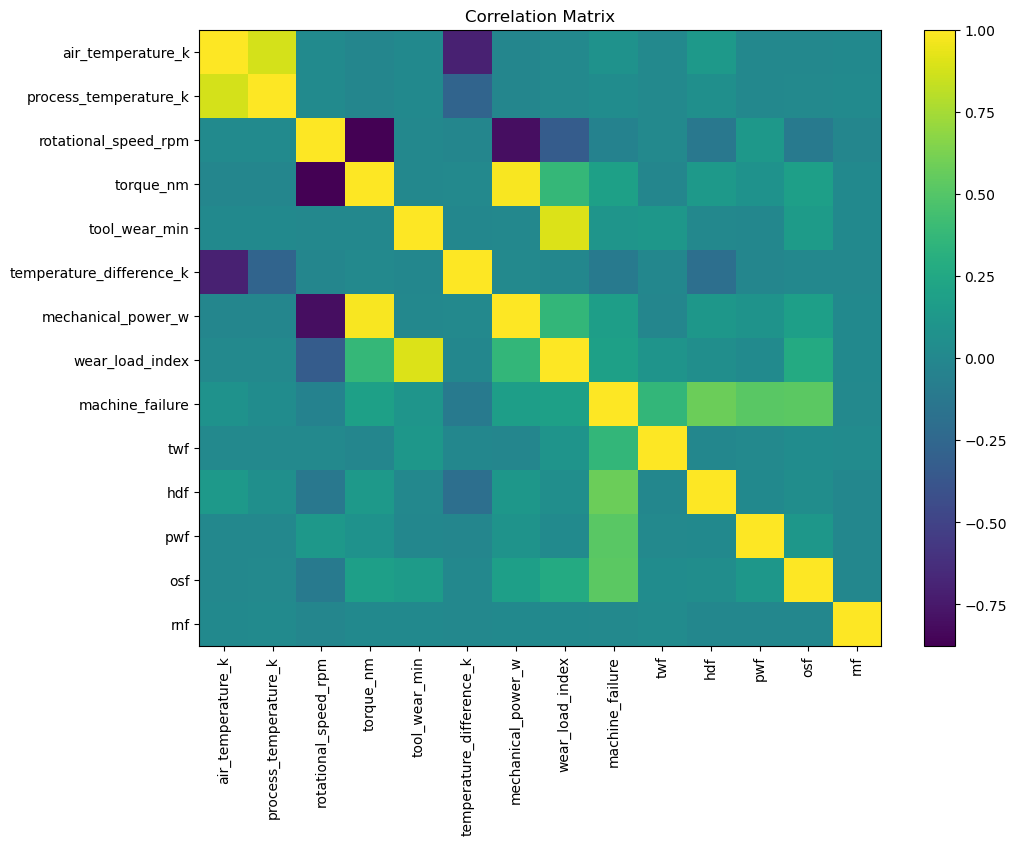

In [23]:
plt.figure(figsize=(11, 8))
image = plt.imshow(corr.values, aspect="auto")
plt.colorbar(image)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix")
plt.show()

### Correlation warning
Correlation is useful for identifying linear relationships, but it does not establish causation. Failure may emerge from threshold effects or interactions that a simple correlation coefficient does not capture.

## 19. Failure Mode Analysis

In [ ]:
failure_modes = ["twf", "hdf", "pwf", "osf", "rnf"]

mode_summary = pd.DataFrame({
    "failure_mode": [m.upper() for m in failure_modes],
    "count": [int(eda[m].sum()) for m in failure_modes],
    "rate_pct": [eda[m].mean() * 100 for m in failure_modes],
}).sort_values("count", ascending=False)

mode_summary

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(mode_summary["failure_mode"], mode_summary["count"])
plt.title("Recorded Failure Modes")
plt.xlabel("Failure Mode")
plt.ylabel("Count")
plt.show()

In [25]:
mode_operating_profile = []

for mode in failure_modes:
    subset = eda[eda[mode] == 1]
    mode_operating_profile.append({
        "failure_mode": mode.upper(),
        "count": len(subset),
        "mean_air_temp_k": subset["air_temperature_k"].mean(),
        "mean_process_temp_k": subset["process_temperature_k"].mean(),
        "mean_temp_difference_k": subset["temperature_difference_k"].mean(),
        "mean_speed_rpm": subset["rotational_speed_rpm"].mean(),
        "mean_torque_nm": subset["torque_nm"].mean(),
        "mean_tool_wear_min": subset["tool_wear_min"].mean(),
        "mean_power_w": subset["mechanical_power_w"].mean(),
        "mean_wear_load": subset["wear_load_index"].mean(),
    })

pd.DataFrame(mode_operating_profile)

NameError: name 'failure_modes' is not defined

## 20. Engineering-Condition Diagnostics

The dataset documentation describes several failure modes using operating conditions. We can translate those descriptions into diagnostic flags and compare them with recorded labels.

These are **EDA rules**, not a machine-learning model.

In [26]:
eda["power_risk_flag"] = (
    (eda["mechanical_power_w"] < 3500)
    | (eda["mechanical_power_w"] > 9000)
).astype(int)

eda["heat_dissipation_risk_flag"] = (
    (eda["temperature_difference_k"] < 8.6)
    & (eda["rotational_speed_rpm"] < 1380)
).astype(int)

type_threshold = eda["type"].map({
    "L": 11000,
    "M": 12000,
    "H": 13000,
})

eda["overstrain_risk_flag"] = (
    eda["wear_load_index"] > type_threshold
).astype(int)

eda[[
    "power_risk_flag",
    "heat_dissipation_risk_flag",
    "overstrain_risk_flag",
]].sum()

power_risk_flag                95
heat_dissipation_risk_flag    115
overstrain_risk_flag           98
dtype: int64

In [27]:
diagnostic_table = pd.DataFrame([
    {
        "condition": "Power outside 3500-9000 W",
        "condition_count": int(eda["power_risk_flag"].sum()),
        "recorded_failure_mode": "PWF",
        "mode_count": int(eda["pwf"].sum()),
        "condition_and_mode": int(((eda["power_risk_flag"] == 1) & (eda["pwf"] == 1)).sum()),
    },
    {
        "condition": "Temperature difference < 8.6 K AND speed < 1380 rpm",
        "condition_count": int(eda["heat_dissipation_risk_flag"].sum()),
        "recorded_failure_mode": "HDF",
        "mode_count": int(eda["hdf"].sum()),
        "condition_and_mode": int(((eda["heat_dissipation_risk_flag"] == 1) & (eda["hdf"] == 1)).sum()),
    },
    {
        "condition": "Wear-load exceeds type-specific threshold",
        "condition_count": int(eda["overstrain_risk_flag"].sum()),
        "recorded_failure_mode": "OSF",
        "mode_count": int(eda["osf"].sum()),
        "condition_and_mode": int(((eda["overstrain_risk_flag"] == 1) & (eda["osf"] == 1)).sum()),
    },
])

diagnostic_table

,condition,condition_count,recorded_failure_mode,mode_count,condition_and_mode
0,Power outside 3500-9000 W,95,PWF,95,95
1,Temperature difference < 8.6 K AND speed < 138...,115,HDF,115,115
2,Wear-load exceeds type-specific threshold,98,OSF,98,98


In [28]:
risk_rate_table = pd.DataFrame({
    "segment": [
        "Overall population",
        "Power-risk observations",
        "Heat-dissipation-risk observations",
        "Overstrain-risk observations",
    ],
    "failure_rate_pct": [
        eda["machine_failure"].mean() * 100,
        eda.loc[eda["power_risk_flag"] == 1, "machine_failure"].mean() * 100,
        eda.loc[eda["heat_dissipation_risk_flag"] == 1, "machine_failure"].mean() * 100,
        eda.loc[eda["overstrain_risk_flag"] == 1, "machine_failure"].mean() * 100,
    ],
})
risk_rate_table

,segment,failure_rate_pct
0,Overall population,3.390
1,Power-risk observations,100.000
2,Heat-dissipation-risk observations,100.000
3,Overstrain-risk observations,100.000


In [ ]:
plt.figure(figsize=(9, 4))
plt.bar(risk_rate_table["segment"], risk_rate_table["failure_rate_pct"])
plt.ylabel("Failure Rate (%)")
plt.title("Failure Rate in Engineering Risk Segments")
plt.xticks(rotation=20)
plt.show()

## 21. Statistical Comparison — Failed vs Normal Observations

In [29]:
test_rows = []

normal = eda[eda["machine_failure"] == 0]
failed = eda[eda["machine_failure"] == 1]

for feature in numeric_features:
    statistic, p_value = mannwhitneyu(
        normal[feature].dropna(),
        failed[feature].dropna(),
        alternative="two-sided",
    )

    test_rows.append({
        "feature": feature,
        "normal_median": normal[feature].median(),
        "failure_median": failed[feature].median(),
        "median_difference": failed[feature].median() - normal[feature].median(),
        "mann_whitney_u": statistic,
        "p_value": p_value,
        "significant_at_0.05": p_value < 0.05,
    })

statistical_tests = pd.DataFrame(test_rows).sort_values("p_value")
statistical_tests

,feature,normal_median,failure_median,median_difference,mann_whitney_u,p_value,significant_at_0.05
3,torque_nm,39.900,53.700,13.800,"752,493.000",0.000,True
2,rotational_speed_rpm,"1,507.000","1,365.000",-142.000,"2,510,959.000",0.000,True
6,mechanical_power_w,"6,243.046","7,611.430","1,368.384","833,008.500",0.000,True
7,wear_load_index,"3,952.800","7,681.800","3,729.000","967,978.500",0.000,True
5,temperature_difference_k,9.800,9.300,-0.500,"2,169,290.000",0.000,True
4,tool_wear_min,107.000,165.000,58.000,"1,106,611.000",0.000,True
0,air_temperature_k,300.000,301.600,1.600,"1,202,819.000",0.000,True
1,process_temperature_k,310.000,310.400,0.400,"1,428,896.500",0.000,True


### Interpretation
A small p-value suggests the two groups have different distributions. It does **not** tell us whether the difference is large enough to matter operationally. Always interpret statistical evidence together with effect size, failure rate and engineering meaning.

## 22. Product Type vs Machine Failure — Chi-Square Test

In [30]:
contingency = pd.crosstab(eda["type"], eda["machine_failure"])
contingency

machine_failure,0,1
type,,
H,982,21
L,5765,235
M,2914,83


In [31]:
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.6g}")
print("Statistically significant at 5% level:", p_value < 0.05)

Chi-square statistic: 13.7517
Degrees of freedom: 2
P-value: 0.00103241
Statistically significant at 5% level: True


## 23. Consistency Check: Failure Flags

In [32]:
eda["specific_failure_count"] = eda[["twf", "hdf", "pwf", "osf", "rnf"]].sum(axis=1)
eda["any_specific_failure"] = (eda["specific_failure_count"] > 0).astype(int)

consistency = pd.crosstab(
    eda["machine_failure"],
    eda["any_specific_failure"],
    rownames=["Machine Failure"],
    colnames=["Any Specific Failure Flag"],
)
consistency

Any Specific Failure Flag,0,1
Machine Failure,,
0,9643,18
1,9,330


In [33]:
multi_mode = eda[eda["specific_failure_count"] > 1][
    ["udi", "product_id", "machine_failure", "twf", "hdf", "pwf", "osf", "rnf", "specific_failure_count"]
]
print("Observations with more than one recorded failure mode:", len(multi_mode))
multi_mode.head(20)

Observations with more than one recorded failure mode: 24


,udi,product_id,machine_failure,twf,hdf,pwf,osf,rnf,specific_failure_count
69,70,L47249,1,0,0,1,1,0,2
1324,1325,M16184,1,0,0,1,1,0,2
1496,1497,L48676,1,0,0,1,1,0,2
3611,3612,L50791,1,1,0,0,0,1,2
3854,3855,L51034,1,0,0,1,1,0,2
3943,3944,L51123,1,0,0,1,1,0,2
4254,4255,L51434,1,0,1,1,0,0,2
4342,4343,M19202,1,0,1,1,0,0,2
4370,4371,L51550,1,0,1,0,1,0,2
4383,4384,L51563,1,0,1,0,1,0,2


## 24. Automatically Generate an Executive Insight Table

In [34]:
overall_failure_rate = eda["machine_failure"].mean() * 100
type_rates = failure_by_type.set_index("type")["failure_rate_pct"]
highest_type = type_rates.idxmax()
highest_type_rate = type_rates.max()

high_wear_rate = eda.loc[eda["tool_wear_min"] > 200, "machine_failure"].mean() * 100
normal_wear_rate = eda.loc[eda["tool_wear_min"] <= 200, "machine_failure"].mean() * 100

insights = pd.DataFrame({
    "Business Question": [
        "How common is failure?",
        "Which product type has the highest observed failure rate?",
        "Does very high tool wear deserve attention?",
        "Does power-risk segmentation identify a higher-risk group?",
        "Does thermal-risk segmentation identify a higher-risk group?",
        "Does overstrain-risk segmentation identify a higher-risk group?",
    ],
    "Data-Driven Answer": [
        f"Overall failure rate = {overall_failure_rate:.2f}%",
        f"Type {highest_type} has the highest observed failure rate = {highest_type_rate:.2f}%",
        f"Tool wear > 200 min failure rate = {high_wear_rate:.2f}% vs {normal_wear_rate:.2f}% at <= 200 min",
        f"Power-risk failure rate = {eda.loc[eda['power_risk_flag']==1, 'machine_failure'].mean()*100:.2f}%",
        f"Thermal-risk failure rate = {eda.loc[eda['heat_dissipation_risk_flag']==1, 'machine_failure'].mean()*100:.2f}%",
        f"Overstrain-risk failure rate = {eda.loc[eda['overstrain_risk_flag']==1, 'machine_failure'].mean()*100:.2f}%",
    ]
})

insights

,Business Question,Data-Driven Answer
0,How common is failure?,Overall failure rate = 3.39%
1,Which product type has the highest observed fa...,Type L has the highest observed failure rate =...
2,Does very high tool wear deserve attention?,Tool wear > 200 min failure rate = 15.49% vs 2...
3,Does power-risk segmentation identify a higher...,Power-risk failure rate = 100.00%
4,Does thermal-risk segmentation identify a high...,Thermal-risk failure rate = 100.00%
5,Does overstrain-risk segmentation identify a h...,Overstrain-risk failure rate = 100.00%


## 25. Business Recommendations

### 1. Monitor combinations of operating variables
A maintenance system should not interpret speed, torque, temperature and wear independently. Several meaningful risk conditions arise from combinations.

### 2. Add a mechanical-power monitoring layer
Speed and torque can be combined into mechanical power. Extreme power regimes should trigger investigation or maintenance review.

### 3. Track thermal-gap deterioration
The difference between process and air temperature provides a clearer thermal indicator than either temperature alone.

### 4. Use tool wear together with load
Tool wear alone does not fully represent stress. A worn tool under high torque can deserve higher priority than a similarly worn tool under low load.

### 5. Keep extreme observations during failure analysis
Outliers may contain the most valuable operational evidence. Remove them only when there is evidence of measurement or data-entry error.

### 6. Report failure rates, not only counts
Maintenance decisions should compare the probability of failure across operating segments. Raw failure counts can be misleading when group sizes differ.

### 7. Treat machine failure as a rare-event problem
In the next modeling phase, avoid judging a classifier only by accuracy. Prioritize precision, recall, F1-score and precision-recall analysis.

## 26. Export Analytical Outputs

In [35]:
quality_summary.to_csv(OUTPUT_DIR / "data_quality_summary.csv")
outlier_summary.to_csv(OUTPUT_DIR / "outlier_summary.csv", index=False)
failure_by_type.to_csv(OUTPUT_DIR / "failure_by_product_type.csv", index=False)
mode_summary.to_csv(OUTPUT_DIR / "failure_mode_summary.csv", index=False)
statistical_tests.to_csv(OUTPUT_DIR / "statistical_tests_numeric.csv", index=False)
diagnostic_table.to_csv(OUTPUT_DIR / "engineering_condition_diagnostics.csv", index=False)
corr.to_csv(OUTPUT_DIR / "correlation_matrix.csv")
insights.to_csv(OUTPUT_DIR / "executive_insights.csv", index=False)
eda.to_csv(OUTPUT_DIR / "ai4i_eda_enriched.csv", index=False)

print("All analytical outputs saved to:", OUTPUT_DIR)

NameError: name 'quality_summary' is not defined

## 27. Final Conclusion

This project demonstrates a complete industry-oriented EDA workflow. The analysis does more than describe columns: it connects raw manufacturing variables to physical operating concepts, compares failure risk across segments, evaluates specific failure modes, applies statistical tests and translates the results into maintenance actions.

### Skills Demonstrated
- Python
- Pandas
- NumPy
- Matplotlib
- SciPy
- Data cleaning
- Data-quality auditing
- Feature engineering
- Univariate, bivariate and multivariate analysis
- Outlier interpretation
- Statistical testing
- Industrial analytics
- Business insight generation
- Predictive-maintenance problem framing

### Recommended Next Project Phase
Build an interpretable machine-failure classification model while explicitly handling class imbalance and evaluating rare-event metrics.